# CortexLab Tutorial: End-to-End Analysis with Synthetic Data

This notebook demonstrates a lightweight CortexLab analysis workflow using synthetic data only.

It follows the repository's documented analysis features and examples:
- brain-alignment benchmarking,
- cognitive load scoring,
- and a notebook-friendly temporal analysis extension.

No GPU or real fMRI data is required for this walkthrough.

## Sections
1. Setup
2. Brain Alignment
3. Cognitive Load
4. Temporal Dynamics
5. Connectivity
6. Modality Attribution
7. Summary

In [39]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)

print("Notebook environment ready!")

Notebook environment ready!


## 1. Setup

In this tutorial, we use synthetic arrays to mimic the shapes expected by CortexLab analysis tools.

We prepare:
- model features for brain-alignment benchmarking,
- synthetic brain predictions across vertices,
- and a small ROI dictionary for region-level summaries.

In [40]:
rng = np.random.default_rng(42)

# synthetic data for brain-alignment benchmarking
n_stimuli = 50
n_vertices = 500
n_timepoints = 30

model_features = rng.normal(size=(n_stimuli, 768))
brain_predictions = rng.normal(size=(n_stimuli, n_vertices))

roi_indices = {
    "V1": np.arange(0, 100),
    "MT": np.arange(100, 200),
    "A1": np.arange(200, 300),
    "Broca": np.arange(300, 400),
    "PFC": np.arange(400, 500),
}

print("model_features shape:", model_features.shape)
print("brain_predictions shape:", brain_predictions.shape)
print("ROIs:", list(roi_indices.keys()))

model_features shape: (50, 768)
brain_predictions shape: (50, 500)
ROIs: ['V1', 'MT', 'A1', 'Broca', 'PFC']


## 2. Brain Alignment

CortexLab includes a brain-alignment benchmark that compares model features against predicted brain responses.

Following the repository example, we score one synthetic feature matrix against one synthetic brain-prediction matrix using multiple methods:
- RSA
- CKA
- Procrustes

In [41]:
# Initialize benchmark
from cortexlab.analysis import BrainAlignmentBenchmark

bench = BrainAlignmentBenchmark(
    brain_predictions,
    roi_indices=roi_indices
)

print("BrainAlignmentBenchmark initialized successfully.")

BrainAlignmentBenchmark initialized successfully.


In [42]:
# Run benchmark
alignment_results = {}

for method in ["rsa", "cka", "procrustes"]:
    result = bench.score_model(model_features, method=method)
    alignment_results[method] = result

    print(f"{method.upper()} aggregate score: {result.aggregate_score:.4f}")
    for roi, score in result.roi_scores.items():
        print(f"  {roi}: {score:.4f}")
    print()

RSA aggregate score: 0.0129
  V1: 0.0356
  MT: -0.0024
  A1: -0.0119
  Broca: -0.0156
  PFC: 0.0166

CKA aggregate score: 0.9267
  V1: 0.8064
  MT: 0.8043
  A1: 0.7811
  Broca: 0.7851
  PFC: 0.7982

PROCRUSTES aggregate score: 0.7818
  V1: 0.5139
  MT: 0.5115
  A1: 0.5015
  Broca: 0.4977
  PFC: 0.5140



The benchmark returns one aggregate score and one score per ROI.

Because this notebook uses random synthetic inputs, the scores do not have neuroscientific meaning.  
They simply demonstrate the analysis interface and output format.

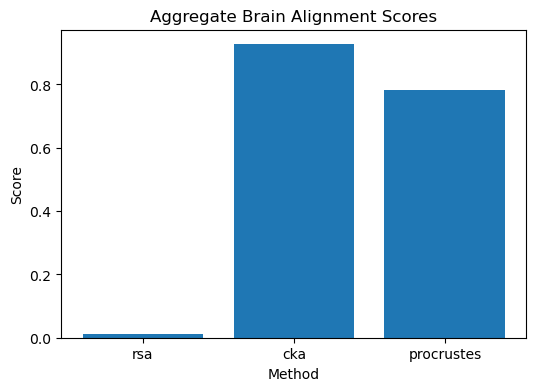

In [43]:
# Aggregate bar chart
methods = list(alignment_results.keys())
aggregate_scores = [alignment_results[m].aggregate_score for m in methods]

plt.figure(figsize=(6, 4))
plt.bar(methods, aggregate_scores)
plt.title("Aggregate Brain Alignment Scores")
plt.xlabel("Method")
plt.ylabel("Score")
plt.show()

### Permutation Test for Statistical Interpretation

To interpret whether an alignment score is larger than chance, we compare the real RSA score against a null distribution generated by shuffling the synthetic feature matrix.

In [47]:
# permutation test code
n_perm = 100
null_scores = []

for _ in range(n_perm):
    shuffled_features = np.random.permutation(model_features)
    shuffled_result = bench.score_model(shuffled_features, method="rsa")
    null_scores.append(shuffled_result.aggregate_score)

real_score = alignment_results["rsa"].aggregate_score

print("Real RSA score:", round(real_score, 4))
print("Mean null RSA score:", round(np.mean(null_scores), 4))

Real RSA score: 0.0129
Mean null RSA score: 0.0059


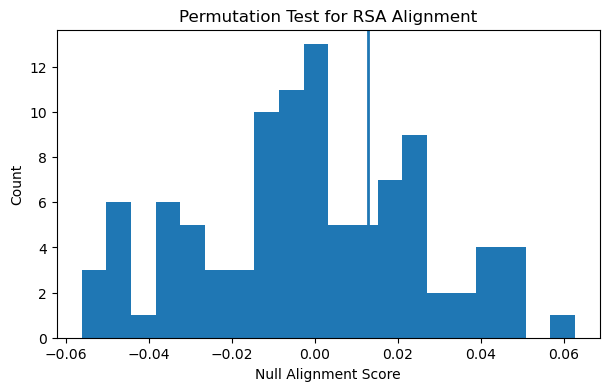

In [46]:
# permutation histogram
plt.figure(figsize=(7, 4))
plt.hist(null_scores, bins=20)
plt.axvline(real_score, linewidth=2)
plt.title("Permutation Test for RSA Alignment")
plt.xlabel("Null Alignment Score")
plt.ylabel("Count")
plt.show()

## 3. Cognitive Load

The repository example also includes a cognitive-load scorer.

Here we create synthetic time-varying predictions and use the scorer to estimate:
- overall load,
- visual complexity,
- auditory demand,
- language processing,
- executive load.

In [38]:
from cortexlab.analysis import CognitiveLoadScorer

scorer = CognitiveLoadScorer(roi_indices, baseline_activation=0.5)
print("CognitiveLoadScorer initialized successfully.")

CognitiveLoadScorer initialized successfully.


In [48]:
# Build time-varying predictions
# synthetic temporal predictions for cognitive-load scoring
n_timepoints = 30
predictions = rng.normal(scale=0.15, size=(n_timepoints, n_vertices))
time = np.arange(n_timepoints)

# build simple time-varying ROI activity patterns
visual_pattern = 0.8 + 0.6 * np.exp(-((time - 9) ** 2) / 18)
auditory_pattern = 0.7 + 0.5 * np.exp(-((time - 20) ** 2) / 20)
language_pattern = 0.2 + 0.35 * np.exp(-((time - 15) ** 2) / 8)
executive_pattern = 0.3 + 0.15 * np.sin(time / 4)

# map patterns to ROI ranges
predictions[:, 0:100] += visual_pattern[:, None]      # V1
predictions[:, 100:200] += visual_pattern[:, None]    # MT
predictions[:, 200:300] += auditory_pattern[:, None]  # A1
predictions[:, 300:400] += language_pattern[:, None]  # Broca
predictions[:, 400:500] += executive_pattern[:, None] # PFC

print("predictions shape:", predictions.shape)

predictions shape: (30, 500)


In [49]:
# Score predictions
load_result = scorer.score_predictions(predictions, tr_seconds=1.0)

print(f"Overall load: {load_result.overall_load:.2f}")
print(f"Visual complexity: {load_result.visual_complexity:.2f}")
print(f"Auditory demand: {load_result.auditory_demand:.2f}")
print(f"Language processing: {load_result.language_processing:.2f}")
print(f"Executive load: {load_result.executive_load:.2f}")
print(f"Timeline length: {len(load_result.timeline)}")

Overall load: 0.50
Visual complexity: 1.00
Auditory demand: 1.00
Language processing: 0.00
Executive load: 0.00
Timeline length: 30


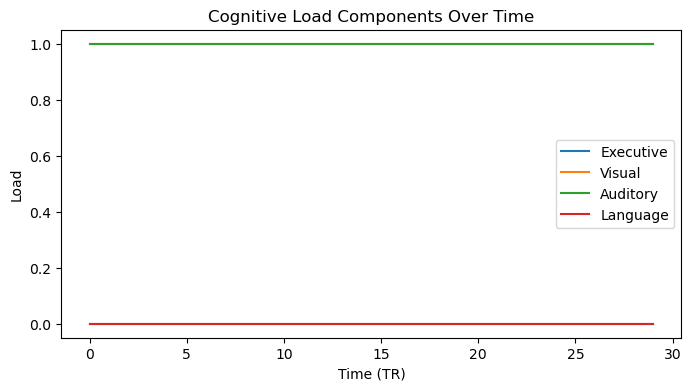

In [50]:
# extract timeline
time_axis = [t for t, _ in load_result.timeline]

# extract component loads
executive = [metrics["executive_load"] for _, metrics in load_result.timeline]
visual = [metrics["visual_complexity"] for _, metrics in load_result.timeline]
auditory = [metrics["auditory_demand"] for _, metrics in load_result.timeline]
language = [metrics["language_processing"] for _, metrics in load_result.timeline]

# plot components
plt.figure(figsize=(8, 4))
plt.plot(time_axis, executive, label="Executive")
plt.plot(time_axis, visual, label="Visual")
plt.plot(time_axis, auditory, label="Auditory")
plt.plot(time_axis, language, label="Language")

plt.title("Cognitive Load Components Over Time")
plt.xlabel("Time (TR)")
plt.ylabel("Load")
plt.legend()
plt.show()

In this toy example, visual demand rises earlier, auditory demand becomes stronger later, and language processing shows a shorter-lived bump.

These trends are synthetic and are included only to make the scorer outputs easier to interpret in notebook form.

## 4. Temporal Dynamics

This section examines how synthetic ROI responses evolve over time.

We focus on three temporal questions:
1. When does each ROI reach its peak response?
2. How does an ROI timecourse align with a model-feature signal across time lags?
3. Can the response be separated into sustained and transient components?

The implementation below follows the repository's temporal-dynamics reference:
ROI timecourse extraction, peak latency, lagged correlation, and moving-average decomposition.

In [52]:
# Helper functions
def get_roi_timecourse(predictions, roi_indices, roi_name):
    """Mean absolute activity within one ROI over time."""
    vertices = roi_indices[roi_name]
    valid = vertices[vertices < predictions.shape[1]]
    if len(valid) == 0:
        return np.zeros(predictions.shape[0])
    return np.abs(predictions[:, valid]).mean(axis=1)


def compute_peak_latency(predictions, roi_indices, roi_name, tr_seconds=1.0):
    """Time to peak ROI response."""
    timecourse = get_roi_timecourse(predictions, roi_indices, roi_name)
    peak_idx = np.argmax(timecourse)
    return peak_idx * tr_seconds, peak_idx, timecourse


def lagged_correlation(brain_tc, model_tc, max_lag_trs=6):
    """Pearson correlation across lags."""
    n = min(len(brain_tc), len(model_tc))
    brain_tc = brain_tc[:n]
    model_tc = model_tc[:n]

    corrs = []
    lags = range(-max_lag_trs, max_lag_trs + 1)

    for lag in lags:
        if lag >= 0:
            b = brain_tc[lag:]
            m = model_tc[: n - lag]
        else:
            b = brain_tc[: n + lag]
            m = model_tc[-lag:]

        if len(b) < 2:
            corrs.append(0.0)
            continue

        b_z = b - b.mean()
        m_z = m - m.mean()
        denom = np.sqrt((b_z ** 2).sum() * (m_z ** 2).sum())

        if denom < 1e-12:
            corrs.append(0.0)
        else:
            corrs.append((b_z * m_z).sum() / denom)

    return np.array(list(lags)), np.array(corrs)


def decompose_response(predictions, roi_indices, roi_name, tr_seconds=1.0, cutoff_seconds=4.0):
    """Split ROI response into sustained and transient components."""
    timecourse = get_roi_timecourse(predictions, roi_indices, roi_name)
    window = max(1, int(cutoff_seconds / tr_seconds))

    kernel = np.ones(window) / window
    sustained = np.convolve(timecourse, kernel, mode="same")
    transient = timecourse - sustained
    return timecourse, sustained, transient

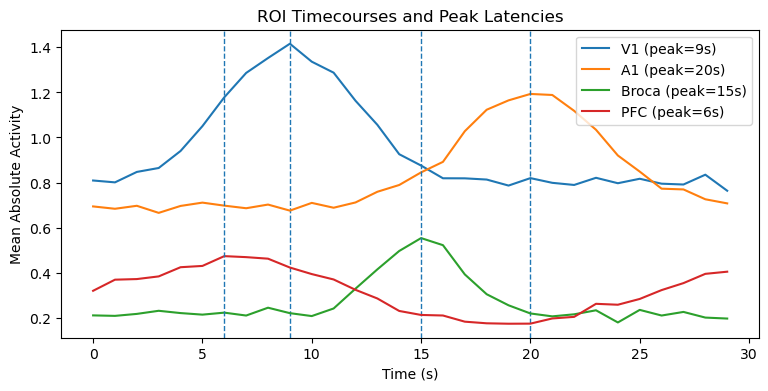

In [53]:
# Plot ROI timecourses and peaks
roi_names = ["V1", "A1", "Broca", "PFC"]
tr_seconds = 1.0
time_axis = np.arange(predictions.shape[0]) * tr_seconds

plt.figure(figsize=(9, 4))

for roi_name in roi_names:
    peak_time, peak_idx, tc = compute_peak_latency(
        predictions, roi_indices, roi_name, tr_seconds=tr_seconds
    )
    plt.plot(time_axis, tc, label=f"{roi_name} (peak={peak_time:.0f}s)")
    plt.axvline(peak_time, linestyle="--", linewidth=1)

plt.title("ROI Timecourses and Peak Latencies")
plt.xlabel("Time (s)")
plt.ylabel("Mean Absolute Activity")
plt.legend()
plt.show()

In [54]:
# Peak summary
for roi_name in roi_names:
    peak_time, peak_idx, _ = compute_peak_latency(
        predictions, roi_indices, roi_name, tr_seconds=tr_seconds
    )
    print(f"{roi_name} peak latency: {peak_time:.1f} s (TR {peak_idx})")

V1 peak latency: 9.0 s (TR 9)
A1 peak latency: 20.0 s (TR 20)
Broca peak latency: 15.0 s (TR 15)
PFC peak latency: 6.0 s (TR 6)


Peak latency is defined here as the time of maximum mean absolute ROI activity.
This follows the temporal reference implementation, which computes time-to-peak from the ROI summary timecourse.

## 5. Connectivity

This section examines ROI-to-ROI relationships from synthetic predicted brain responses.

Following the repository connectivity reference, we:
1. compute an ROI correlation matrix,
2. cluster ROIs into functional groups,
3. derive simple graph metrics from thresholded connectivity.

Because the notebook uses synthetic data, these connectivity patterns are only illustrative.

In [55]:
# Helper functions
from scipy.cluster.hierarchy import fcluster, linkage


def compute_connectivity_matrix(predictions, roi_indices):
    """Compute ROI-to-ROI correlation matrix from mean ROI timecourses."""
    roi_names = list(roi_indices.keys())
    n_rois = len(roi_names)
    T = predictions.shape[0]

    timecourses = np.zeros((n_rois, T))

    for i, name in enumerate(roi_names):
        vertices = roi_indices[name]
        valid = vertices[vertices < predictions.shape[1]]
        if len(valid) > 0:
            timecourses[i] = predictions[:, valid].mean(axis=1)

    if T < 2:
        return np.eye(n_rois), roi_names, timecourses

    corr_matrix = np.corrcoef(timecourses)
    corr_matrix = np.nan_to_num(corr_matrix, nan=0.0)

    return corr_matrix, roi_names, timecourses


def cluster_rois(correlation_matrix, roi_names, n_clusters=3):
    """Cluster ROIs using 1 - |correlation| distance."""
    n = correlation_matrix.shape[0]
    n_clusters = min(n_clusters, n)

    dist = 1.0 - np.abs(correlation_matrix)
    np.fill_diagonal(dist, 0.0)

    condensed = []
    for i in range(n):
        for j in range(i + 1, n):
            condensed.append(dist[i, j])
    condensed = np.array(condensed)

    Z = linkage(condensed, method="average")
    labels = fcluster(Z, t=n_clusters, criterion="maxclust")

    clusters = {}
    for roi_name, cluster_id in zip(roi_names, labels):
        cid = int(cluster_id)
        if cid not in clusters:
            clusters[cid] = []
        clusters[cid].append(roi_name)

    return clusters


def compute_graph_metrics(correlation_matrix, roi_names, threshold=0.3):
    """Compute simple degree-based graph metrics."""
    n = correlation_matrix.shape[0]
    adj = (np.abs(correlation_matrix) > threshold).astype(float)
    np.fill_diagonal(adj, 0.0)

    degree = adj.sum(axis=1)
    max_degree = max(n - 1, 1)

    degree_centrality = {
        name: float(degree[i] / max_degree) for i, name in enumerate(roi_names)
    }
    mean_degree = float(degree.mean() / max_degree)

    return {
        "degree_centrality": degree_centrality,
        "mean_degree": mean_degree,
    }

In [56]:
# Run connectivity analysis
corr_matrix, conn_roi_names, roi_timecourses = compute_connectivity_matrix(
    predictions, roi_indices
)

clusters = cluster_rois(corr_matrix, conn_roi_names, n_clusters=3)
graph_metrics = compute_graph_metrics(corr_matrix, conn_roi_names, threshold=0.3)

print("Connectivity matrix shape:", corr_matrix.shape)
print("ROI order:", conn_roi_names)
print("\nClusters:")
for cid, members in clusters.items():
    print(f"  Cluster {cid}: {members}")

print("\nGraph metrics:")
print("Mean degree:", round(graph_metrics["mean_degree"], 3))
for roi, score in graph_metrics["degree_centrality"].items():
    print(f"  {roi}: {score:.3f}")

Connectivity matrix shape: (5, 5)
ROI order: ['V1', 'MT', 'A1', 'Broca', 'PFC']

Clusters:
  Cluster 1: ['V1', 'MT']
  Cluster 2: ['A1', 'PFC']
  Cluster 3: ['Broca']

Graph metrics:
Mean degree: 0.7
  V1: 0.750
  MT: 0.750
  A1: 0.750
  Broca: 0.250
  PFC: 1.000


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


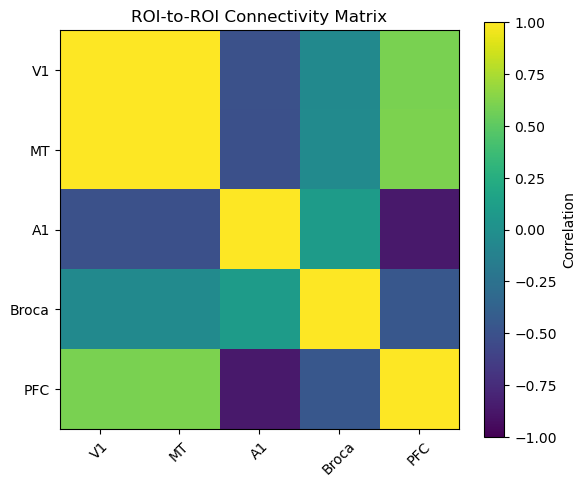

In [57]:
# Plot correlation matrix
plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(conn_roi_names)), conn_roi_names, rotation=45)
plt.yticks(range(len(conn_roi_names)), conn_roi_names)
plt.title("ROI-to-ROI Connectivity Matrix")
plt.tight_layout()
plt.show()

The matrix summarizes pairwise Pearson correlation between ROI mean timecourses.

In this toy example, stronger positive values indicate that two ROIs follow similar temporal patterns across the synthetic prediction sequence.

In [59]:
print("Functional ROI clusters:")
for cid, members in clusters.items():
    print(f"Cluster {cid}: {members}")

Functional ROI clusters:
Cluster 1: ['V1', 'MT']
Cluster 2: ['A1', 'PFC']
Cluster 3: ['Broca']


The clustering step groups ROIs using similarity in their temporal activity patterns.

In this toy example, visual regions such as V1 and MT are expected to cluster together because they share similar synthetic response profiles.

## 6. Modality Attribution

CortexLab also supports modality attribution as part of its inference toolkit.

According to the repository documentation, this feature produces **per-vertex importance scores for text, audio, and video**, helping interpret which modality contributes most to predicted brain activity.

Because this notebook focuses on the repository’s lightweight synthetic analysis workflow, and a minimal standalone attribution example is not yet documented in the repository examples, this section is intentionally left as a placeholder for future expansion.

## 7. Summary

In this notebook, we used synthetic data to demonstrate a lightweight CortexLab analysis workflow.

We covered:
- setup of synthetic feature and prediction arrays,
- brain-alignment benchmarking,
- permutation-based interpretation for RSA,
- cognitive-load scoring over time,
- temporal analysis of ROI responses,
- and ROI-to-ROI connectivity analysis.

A modality-attribution walkthrough can be added later once a dedicated tutorial example is available.